In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("D:\EDAV Assignment\Sample-Superstore.csv",encoding='latin1')
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.month
df['Year'] = df['Order Date'].dt.year
df['YearMonth'] = df['Order Date'].dt.to_period('M')

## Q1. Monthly Sales Trend by Category
Create a multi-line plot of monthly sales trends for each product Category over all years. Identify seasonal peaks and consistent growth patterns.

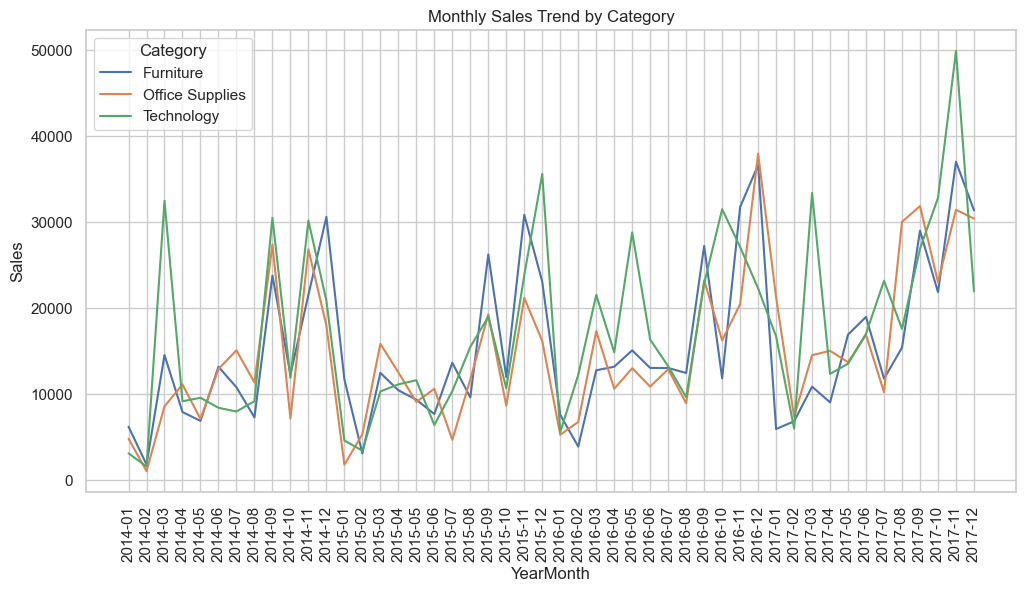

In [2]:
monthly_sales = df.groupby(['YearMonth','Category'])['Sales'].sum().reset_index()
monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

plt.figure(figsize=(12,6))
sns.lineplot(data=monthly_sales, x='YearMonth', y='Sales', hue='Category')
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend by Category")
plt.show()

**Analysis:**  
Technology category shows consistent growth over time.  
Seasonal peaks appear around year-end months indicating higher holiday sales.  
Furniture and Office Supplies remain relatively stable with moderate fluctuations.

## Q2. Discount vs Profit Scatter Plot
Generate a scatter plot of Discount vs Profit colored by Category. Add a horizontal reference line at Profit = 0.

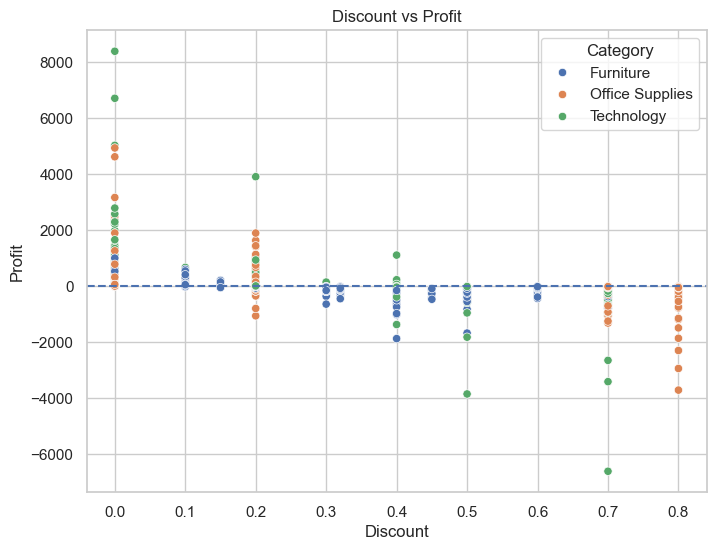

In [3]:
plt.figure(figsize=(8,6))
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category')
plt.axhline(0, linestyle='--')
plt.title("Discount vs Profit")
plt.show()

**Analysis:**  
Higher discounts generally lead to lower profits.  
Losses are frequent when discount exceeds around 0.2–0.3.  
Technology products handle discounts better compared to Furniture.

## Q3. Sales Distribution Histogram
Visualize the distribution of Sales using histogram with KDE curve.

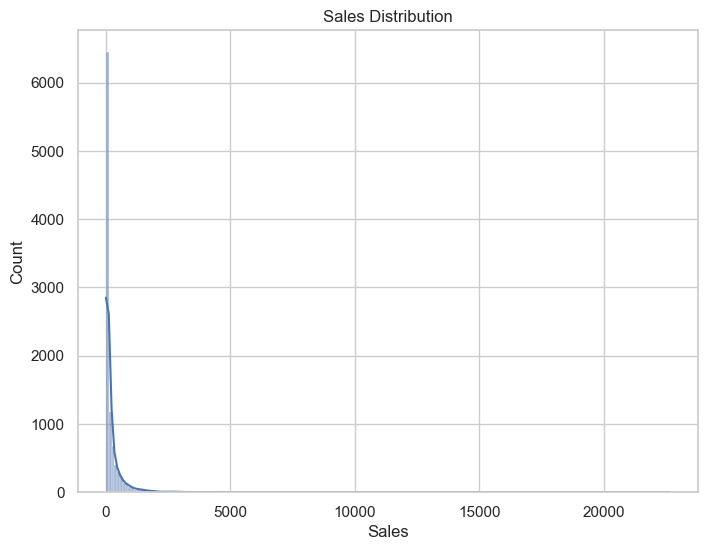

In [4]:
plt.figure(figsize=(8,6))
sns.histplot(df['Sales'], kde=True, bins='auto')
plt.title("Sales Distribution")
plt.show()

**Analysis:**  
Most orders fall within the lower sales range.  
Distribution is right-skewed with few high-value orders.  
Typical order value appears below 500.

## Q4. Profit Density by Region
Create KDE plot of Profit grouped by Region.

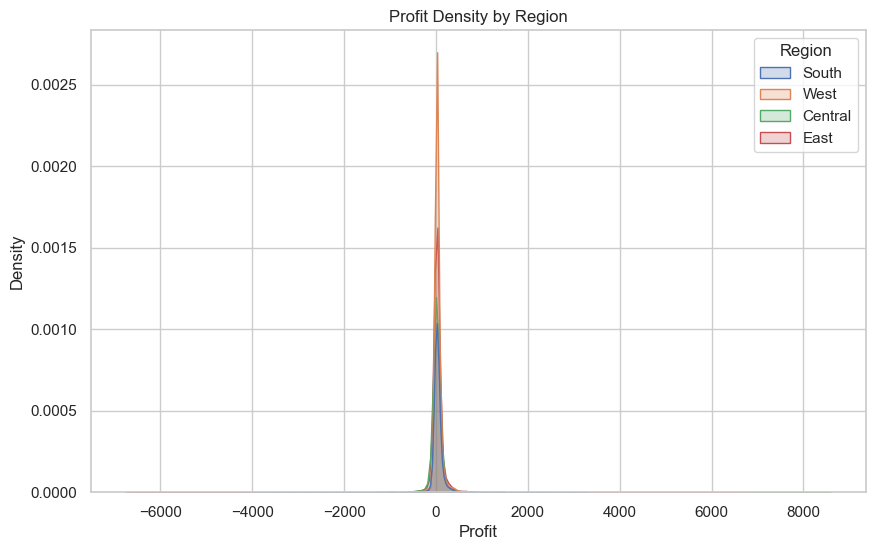

In [5]:
plt.figure(figsize=(10,6))
sns.kdeplot(data=df, x='Profit', hue='Region', fill=True)
plt.title("Profit Density by Region")
plt.show()

**Analysis:**  
West region shows more consistent positive profits.  
Central region displays wider spread indicating volatility.  
Some regions show negative profit density.

## Q5. 2D Density Plot Sales vs Profit
Compare joint distributions for each Category.

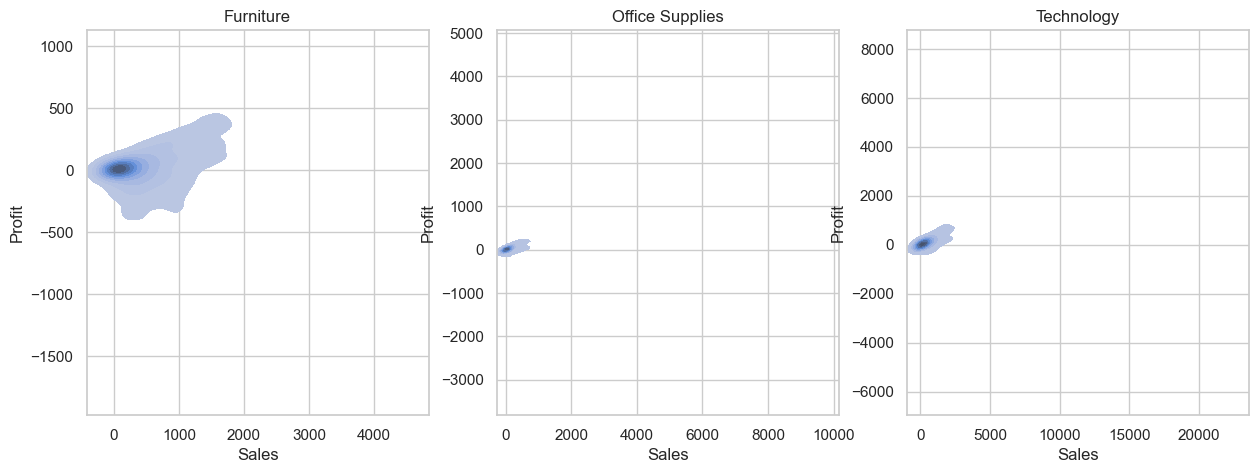

In [6]:
categories = df['Category'].unique()
fig, axes = plt.subplots(1,3, figsize=(15,5))

for i, cat in enumerate(categories):
    subset = df[df['Category']==cat]
    sns.kdeplot(data=subset, x='Sales', y='Profit', fill=True, ax=axes[i])
    axes[i].set_title(cat)

plt.show()

**Analysis:**  
Technology category shows higher profit concentration.  
Furniture has more loss regions.  
Office Supplies show moderate performance.

## Q6. Error Bars for Average Profit per Sub-Category
Visualize mean ± standard deviation.

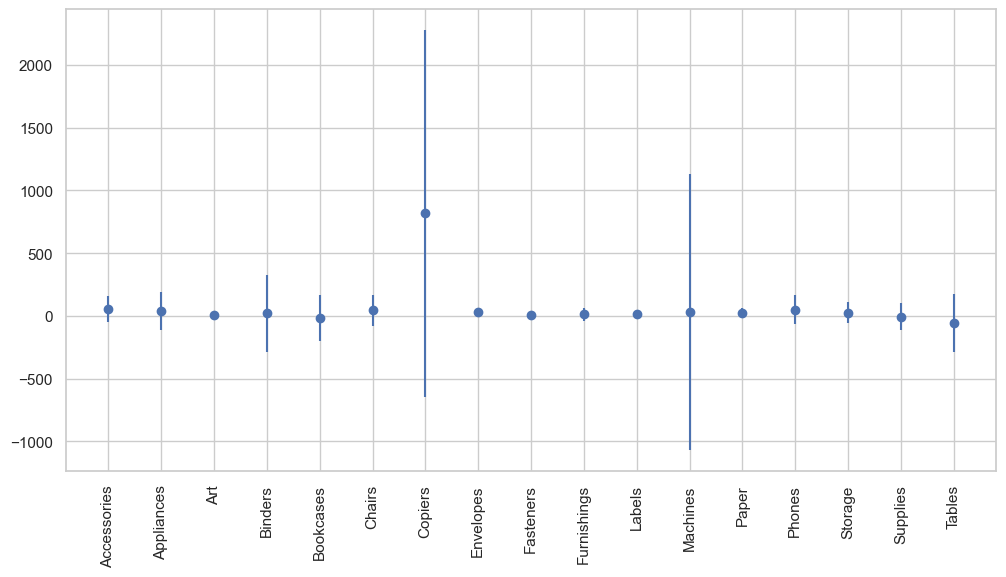

In [7]:
profit_stats = df.groupby('Sub-Category')['Profit'].agg(['mean','std']).reset_index()

plt.figure(figsize=(12,6))
plt.errorbar(profit_stats['Sub-Category'], profit_stats['mean'],
             yerr=profit_stats['std'], fmt='o')
plt.xticks(rotation=90)
plt.show()

**Analysis:**  
Large error bars indicate volatile sub-categories.  
Small error bars show consistent profit margins.  
Some sub-categories show negative average profit.

## Q7. Multiple Visualization Grid
Create 3x2 subplot showing different visualizations.

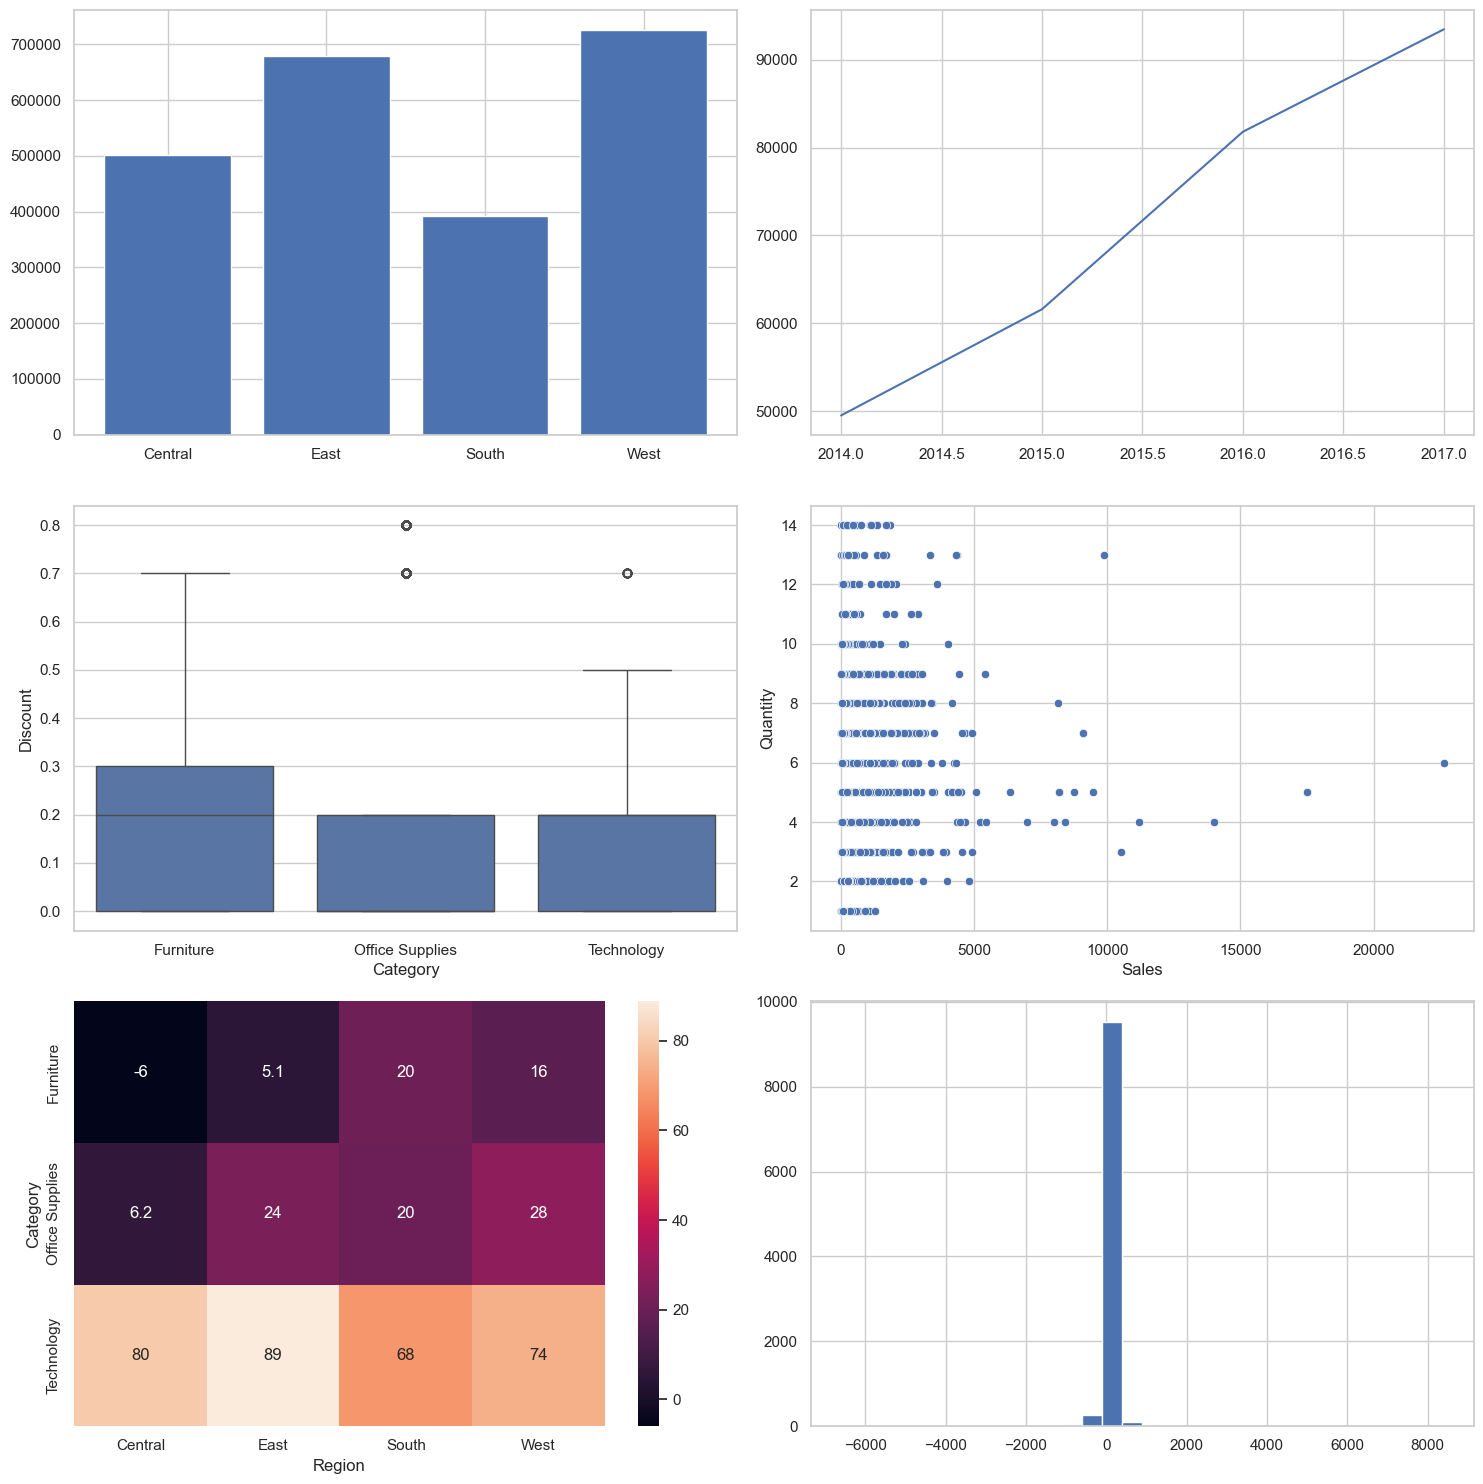

In [8]:
fig, axes = plt.subplots(3,2, figsize=(15,15))

region_sales = df.groupby('Region')['Sales'].sum()
axes[0,0].bar(region_sales.index, region_sales.values)

year_profit = df.groupby('Year')['Profit'].sum()
axes[0,1].plot(year_profit.index, year_profit.values)

sns.boxplot(data=df, x='Category', y='Discount', ax=axes[1,0])
sns.scatterplot(data=df, x='Sales', y='Quantity', ax=axes[1,1])

pivot = df.pivot_table(values='Profit', index='Category', columns='Region')
sns.heatmap(pivot, annot=True, ax=axes[2,0])

axes[2,1].hist(df['Profit'], bins=30)

plt.tight_layout()
plt.show()

**Analysis:**  
West region leads in total sales.  
Profit trend shows gradual growth across years.  
Discount distribution varies across categories.

## Q8. Yearly Profit Trend per Segment
Use lineplot with confidence intervals.

C:\Users\DELL\AppData\Local\Temp\ipykernel_6864\2843493924.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=df, x='Year', y='Profit', hue='Segment', ci=95)


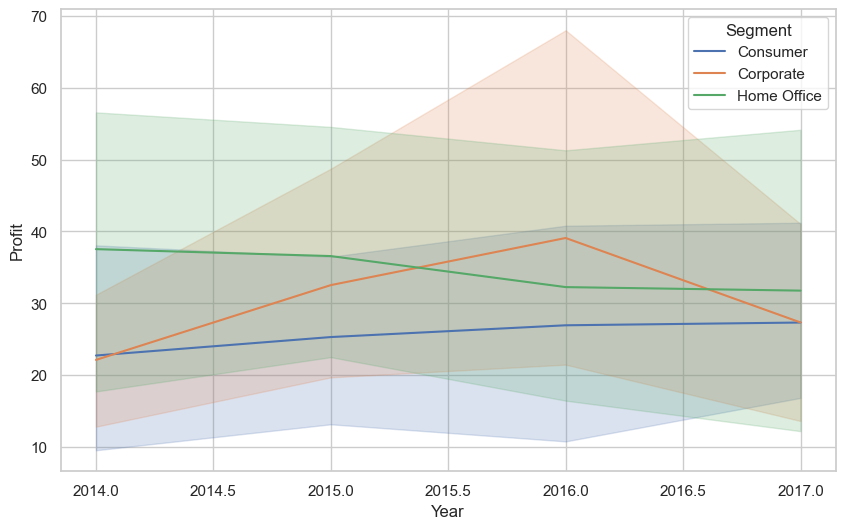

In [9]:
plt.figure(figsize=(10,6))
sns.lineplot(data=df, x='Year', y='Profit', hue='Segment', ci=95)
plt.show()

**Analysis:**  
Consumer segment shows fastest growth.  
Corporate remains stable.  
Home Office has fluctuating trend.

## Q9. Heatmap of Average Profit by Sub-Category and Region

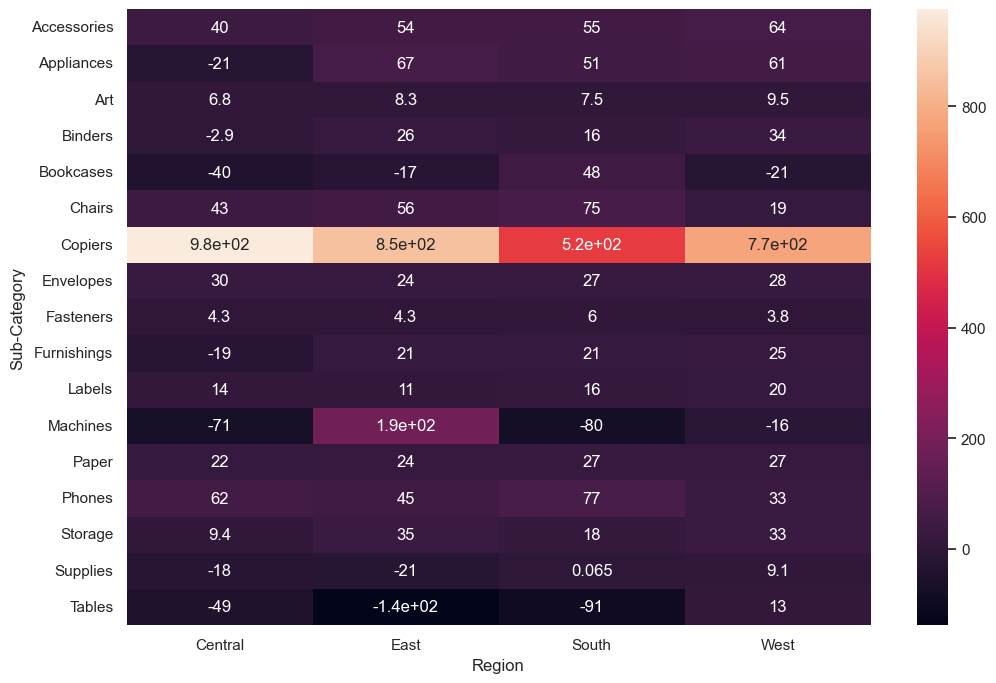

In [10]:
pivot = df.pivot_table(values='Profit',
                       index='Sub-Category',
                       columns='Region',
                       aggfunc='mean')

plt.figure(figsize=(12,8))
sns.heatmap(pivot, annot=True)
plt.show()

**Analysis:**  
Certain sub-categories perform better in specific regions.  
Negative values highlight loss areas.  
Heatmap helps identify regional champions.

## Q10. FacetGrid Profit Distribution by Shipping Mode

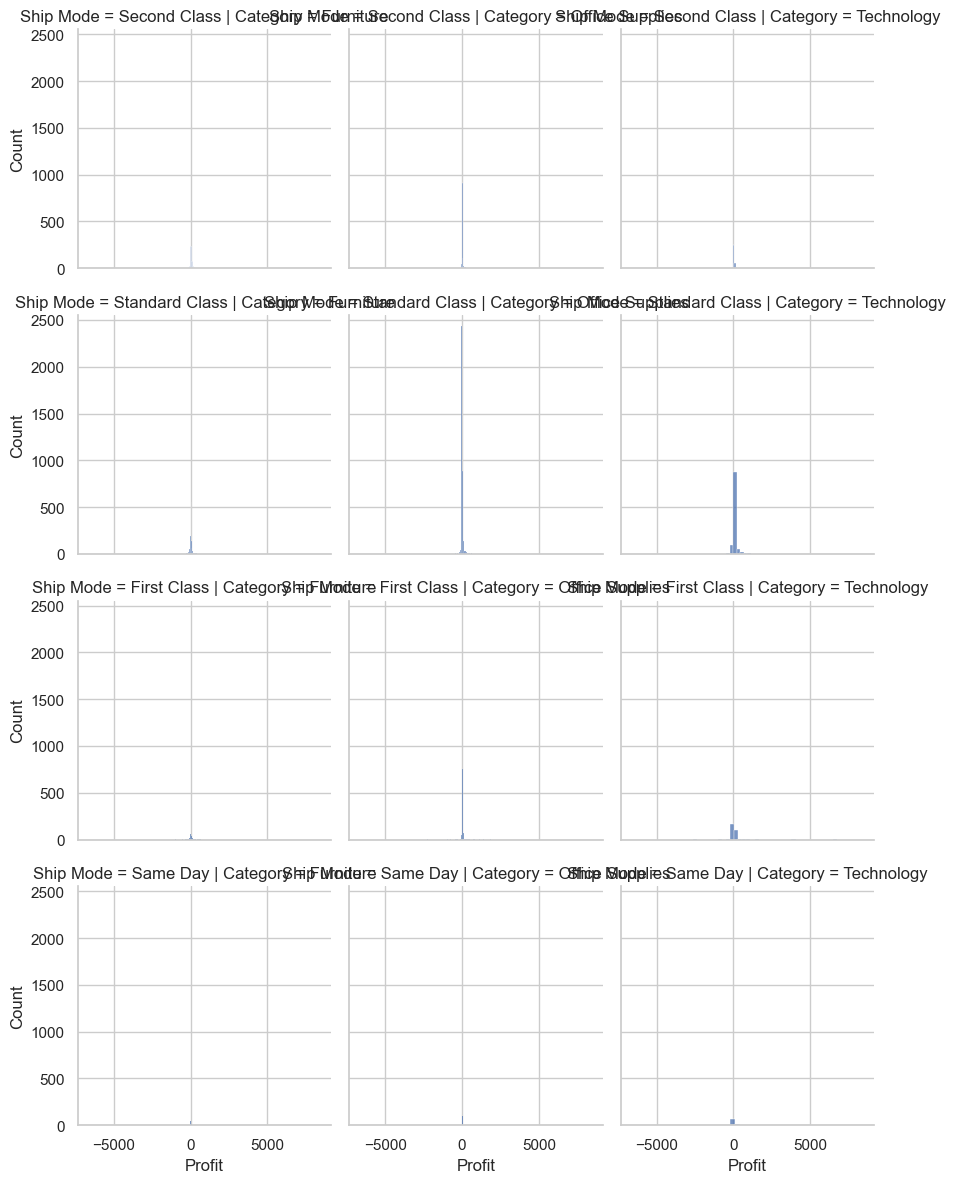

In [11]:
g = sns.FacetGrid(df, col="Category", row="Ship Mode")
g.map(sns.histplot, "Profit")
plt.show()

**Analysis:**  
Standard shipping shows stable profit distribution.  
Same-day shipping appears more volatile.  
Optimal shipping varies by category.

## Overall Analysis

The Superstore dataset visualization reveals key business insights across sales, profit, discount, and regional performance. 
Monthly sales trends show that the Technology category demonstrates consistent growth, while Furniture and Office Supplies exhibit moderate seasonal fluctuations. 
The scatter analysis between discount and profit indicates that higher discounts often lead to losses, particularly beyond moderate discount levels.

Sales distribution is highly right-skewed, meaning most orders are low-value with few large transactions. 
Profit density plots show that the West region maintains more consistent profitability, while the Central region appears more volatile. 
Joint density comparisons indicate that Technology is the healthiest category with higher profit concentration.

Error bar visualization highlights certain sub-categories with high volatility in profits, suggesting unstable margins. 
Multi-plot analysis confirms that regional performance varies significantly, with some regions contributing more to total sales and profits. 
Segment-based trend analysis shows that the Consumer segment is growing faster compared to Corporate and Home Office segments.

Heatmap analysis reveals regional champions among sub-categories, helping identify strong product-region combinations. 
FacetGrid visualization suggests that standard shipping methods tend to produce more stable profits, while faster shipping modes show higher variability.

Overall, the analysis suggests focusing on Technology products, controlling excessive discounts, optimizing shipping strategies, and strengthening high-performing regions to improve profitability.